In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

df1 = pd.read_csv(r'C:\Users\sahil\india_project\data\literacy_rate.csv')
df2 = pd.read_csv(r'C:\Users\sahil\india_project\data\unemployment_rate.csv')
df3 = pd.read_csv(r'C:\Users\sahil\india_project\data\education_stats.csv')

print("Dataset 1:", df1.shape)
print("Dataset 2:", df2.shape)
print("Dataset 3:", df3.shape)

Dataset 1: (110, 14)
Dataset 2: (32, 13)
Dataset 3: (36, 816)


In [3]:
numeric_cols = [
    'Primary_Boys', 'Primary_Girls', 'Primary_Total',
    'Upper Primary_Boys', 'Upper Primary_Girls', 'Upper Primary_Total',
    'Secondary _Boys', 'Secondary _Girls', 'Secondary _Total',
    'HrSecondary_Boys', 'HrSecondary_Girls', 'HrSecondary_Total'
]

for col in numeric_cols:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')

for col in numeric_cols:
    df1[col] = df1[col].fillna(df1[col].median())

print("Dataset 1 cleaned. Missing values:")
print(df1[numeric_cols].isnull().sum().sum())
print(df1.shape)

Dataset 1 cleaned. Missing values:
0
(110, 14)


In [5]:
df2 = df2.rename(columns={
    'States_Union Territories' : 'state',
    '2000-01-INC'              : 'income_2001',
    '2011-12-INC'              : 'income_2011',
    '2001 - LIT'               : 'literacy_2001',
    '2011- LIT'                : 'literacy_2011',
    '2001 - POP'               : 'population_2001',
    '2011- POP'                : 'population_2011',
    '2001 -SEX_Ratio'          : 'sex_ratio_2001',
    '2011 -SEX_Ratio'          : 'sex_ratio_2011',
    '2001 -UNEMP'              : 'unemployment_2001',
    '2011 -UNEMP'              : 'unemployment_2011',
    '2001 -Poverty'            : 'poverty_2001',
    '2011 -Poverty'            : 'poverty_2011'
})

print("Dataset 2 cleaned. Columns:")
print(df2.columns.tolist())
print(df2.shape)

Dataset 2 cleaned. Columns:
['state', 'income_2001', 'income_2011', 'literacy_2001', 'literacy_2011', 'population_2001', 'population_2011', 'sex_ratio_2001', 'sex_ratio_2011', 'unemployment_2001', 'unemployment_2011', 'poverty_2001', 'poverty_2011']
(32, 13)


In [7]:
corrections = {
    'Kerala'           : 93.91,
    'Mizoram'          : 87.75,
    'Tripura'          : 82.14,
    'Goa'              : 79.63,
    'Himachal Pradesh' : 78.57,
    'Maharashtra'      : 76.99,
    'Bihar'            : 63.82,
    'Rajasthan'        : 67.07
}

for state, value in corrections.items():
    df2.loc[df2['state'] == state, 'literacy_2011'] = value

print("Literacy values corrected for 8 states using Census 2011 data.")
print(df2[['state','literacy_2011']].sort_values('literacy_2011', ascending=False).head(10))

Literacy values corrected for 8 states using Census 2011 data.
                          state  literacy_2011
15                       Kerala          93.91
18                      Manipur          91.85
23                   Puducherry          91.33
10                      Haryana          88.70
20                      Mizoram          87.75
30                  Uttarakhand          87.22
0   Andaman and Nicobar Islands          86.63
9                       Gujarat          86.21
5                    Chandigarh          86.05
26                       Sikkim          85.85


In [9]:
df3_clean = df3[[
    'AC_YEAR', 'STATNAME', 'TOTPOPULAT', 'OVERALL_LI',
    'FEMALE_LIT', 'MALE_LIT', 'ENRTOT', 'ENRTOTG',
    'ENRTOTP', 'SCHTOT', 'TCHTOT'
]].copy()

df3_clean = df3_clean.rename(columns={
    'AC_YEAR'    : 'year',
    'STATNAME'   : 'state',
    'TOTPOPULAT' : 'total_population',
    'OVERALL_LI' : 'overall_literacy',
    'FEMALE_LIT' : 'female_literacy',
    'MALE_LIT'   : 'male_literacy',
    'ENRTOT'     : 'total_enrollment',
    'ENRTOTG'    : 'girl_enrollment',
    'ENRTOTP'    : 'private_enrollment',
    'SCHTOT'     : 'total_schools',
    'TCHTOT'     : 'total_teachers'
})

print("Dataset 3 cleaned.")
print(df3_clean.shape)
print(df3_clean.head(3))

Dataset 3 cleaned.
(36, 11)
      year             state  total_population  overall_literacy  \
0  2015-16   JAMMU & KASHMIR             12549             68.74   
1  2015-16  HIMACHAL PRADESH              6857             83.78   
2  2015-16            PUNJAB             27704             76.68   

   female_literacy  male_literacy  total_enrollment  girl_enrollment  \
0            58.01          78.26           1856776          1024643   
1            76.60          90.83            950766           580395   
2            71.34          81.48           3962439          2072324   

   private_enrollment  total_schools  total_teachers  
0              832077          28578          157847  
1              370337          18024           94865  
2             1651510          28776          250470  


In [11]:
df1.to_csv(r'C:\Users\sahil\india_project\data\clean_dropout.csv', index=False)
df2.to_csv(r'C:\Users\sahil\india_project\data\clean_unemployment.csv', index=False)
df3_clean.to_csv(r'C:\Users\sahil\india_project\data\clean_education.csv', index=False)

print("All 3 clean datasets saved.")

All 3 clean datasets saved.


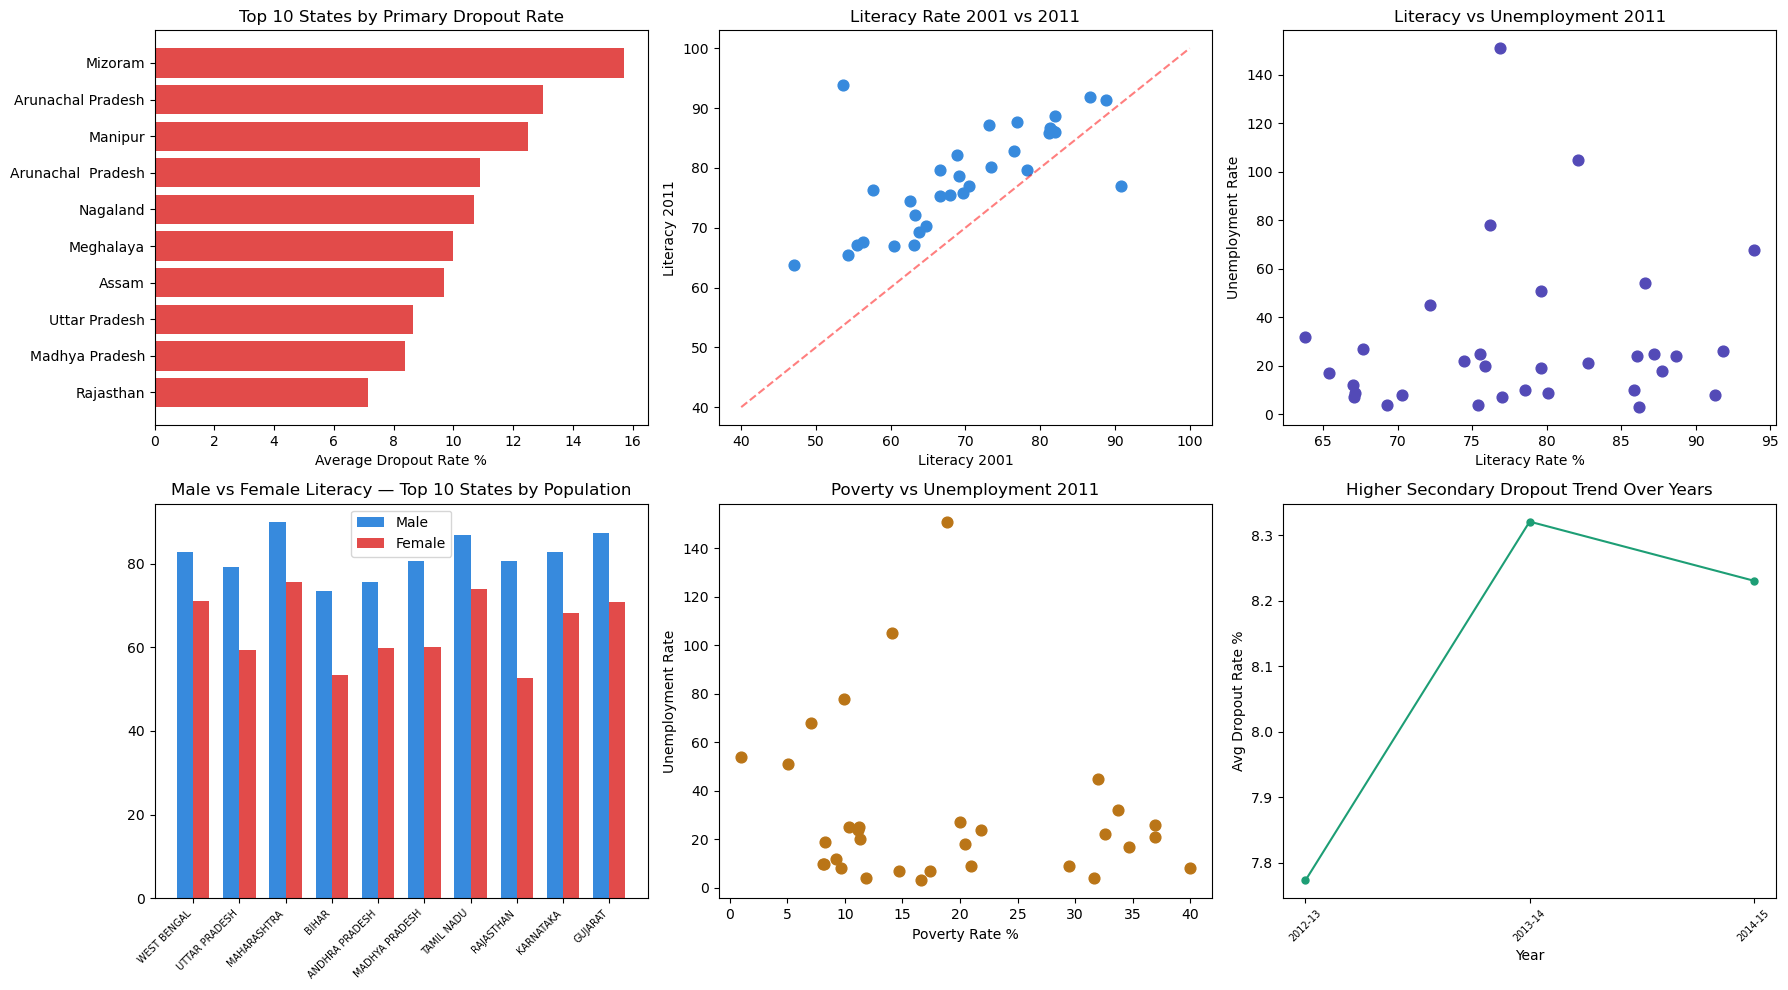

EDA plots saved.


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1 — Top 10 states by dropout rate
top_dropout = df1.groupby('State_UT')['Primary_Total'].mean().sort_values(ascending=False).head(10)
axes[0,0].barh(top_dropout.index[::-1], top_dropout.values[::-1], color='#E24B4A')
axes[0,0].set_title('Top 10 States by Primary Dropout Rate')
axes[0,0].set_xlabel('Average Dropout Rate %')

# Plot 2 — Literacy rate 2001 vs 2011 scatter
axes[0,1].scatter(df2['literacy_2001'], df2['literacy_2011'], color='#378ADD', s=60)
axes[0,1].plot([40,100],[40,100], 'r--', alpha=0.5)
axes[0,1].set_title('Literacy Rate 2001 vs 2011')
axes[0,1].set_xlabel('Literacy 2001')
axes[0,1].set_ylabel('Literacy 2011')

# Plot 3 — Unemployment vs Literacy 2011
axes[0,2].scatter(df2['literacy_2011'], df2['unemployment_2011'], color='#534AB7', s=60)
axes[0,2].set_title('Literacy vs Unemployment 2011')
axes[0,2].set_xlabel('Literacy Rate %')
axes[0,2].set_ylabel('Unemployment Rate')

# Plot 4 — Male vs Female literacy
top_states = df3_clean.nlargest(10, 'total_population')
x = range(len(top_states))
width = 0.35
axes[1,0].bar([i-width/2 for i in x], top_states['male_literacy'], width, label='Male', color='#378ADD')
axes[1,0].bar([i+width/2 for i in x], top_states['female_literacy'], width, label='Female', color='#E24B4A')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(top_states['state'], rotation=45, ha='right', fontsize=7)
axes[1,0].set_title('Male vs Female Literacy — Top 10 States by Population')
axes[1,0].legend()

# Plot 5 — Poverty vs Unemployment
axes[1,1].scatter(df2['poverty_2011'], df2['unemployment_2011'], color='#BA7517', s=60)
axes[1,1].set_title('Poverty vs Unemployment 2011')
axes[1,1].set_xlabel('Poverty Rate %')
axes[1,1].set_ylabel('Unemployment Rate')

# Plot 6 — HrSecondary dropout trend
yearly_dropout = df1.groupby('year')['HrSecondary_Total'].mean()
axes[1,2].plot(range(len(yearly_dropout)), yearly_dropout.values, color='#1D9E75', marker='o', ms=5)
axes[1,2].set_xticks(range(len(yearly_dropout)))
axes[1,2].set_xticklabels(yearly_dropout.index, rotation=45, fontsize=7)
axes[1,2].set_title('Higher Secondary Dropout Trend Over Years')
axes[1,2].set_xlabel('Year')
axes[1,2].set_ylabel('Avg Dropout Rate %')

plt.tight_layout()
plt.savefig(r'C:\Users\sahil\india_project\screenshots\01_eda_full.png', dpi=150)
plt.show()
print("EDA plots saved.")

C:\Users\sahil\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\sahil\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
C:\Users\sahil\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


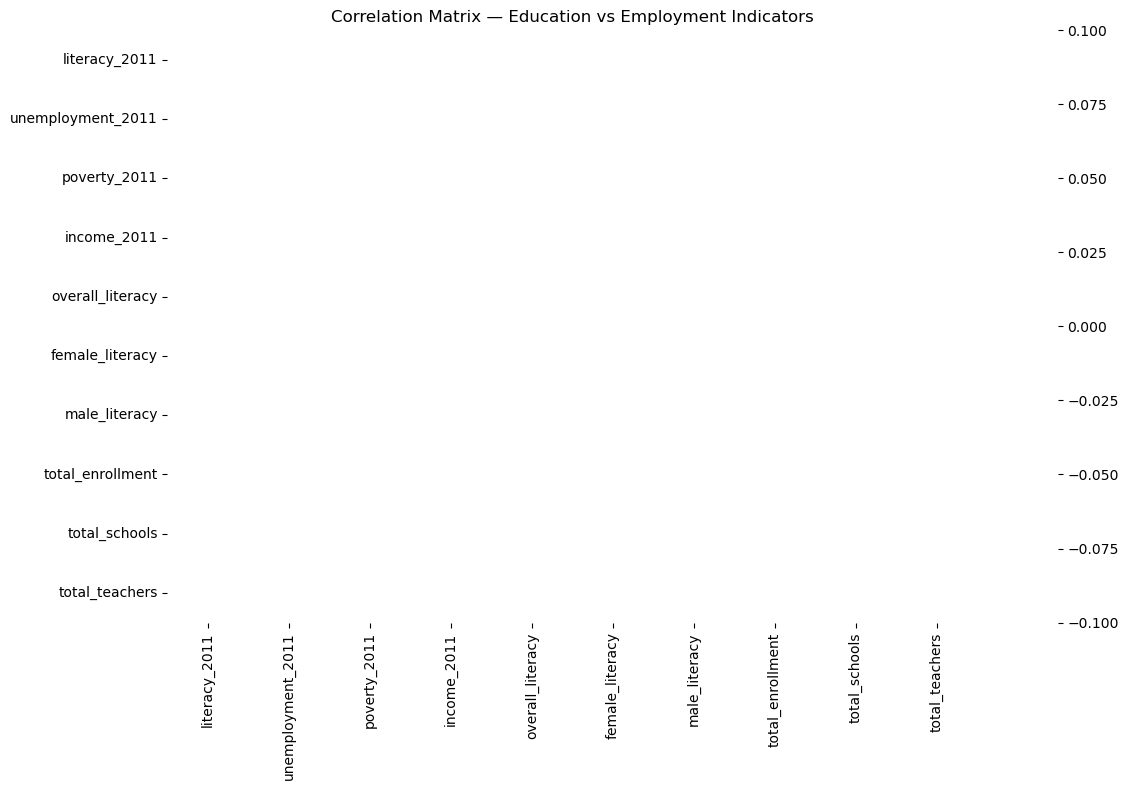

Correlation heatmap saved.


In [15]:
merged = df2.merge(df3_clean, on='state', how='inner')

corr_cols = [
    'literacy_2011', 'unemployment_2011', 'poverty_2011', 'income_2011',
    'overall_literacy', 'female_literacy', 'male_literacy',
    'total_enrollment', 'total_schools', 'total_teachers'
]

corr_matrix = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Correlation Matrix — Education vs Employment Indicators')
plt.tight_layout()
plt.savefig(r'C:\Users\sahil\india_project\screenshots\02_correlation.png', dpi=150)
plt.show()
print("Correlation heatmap saved.")

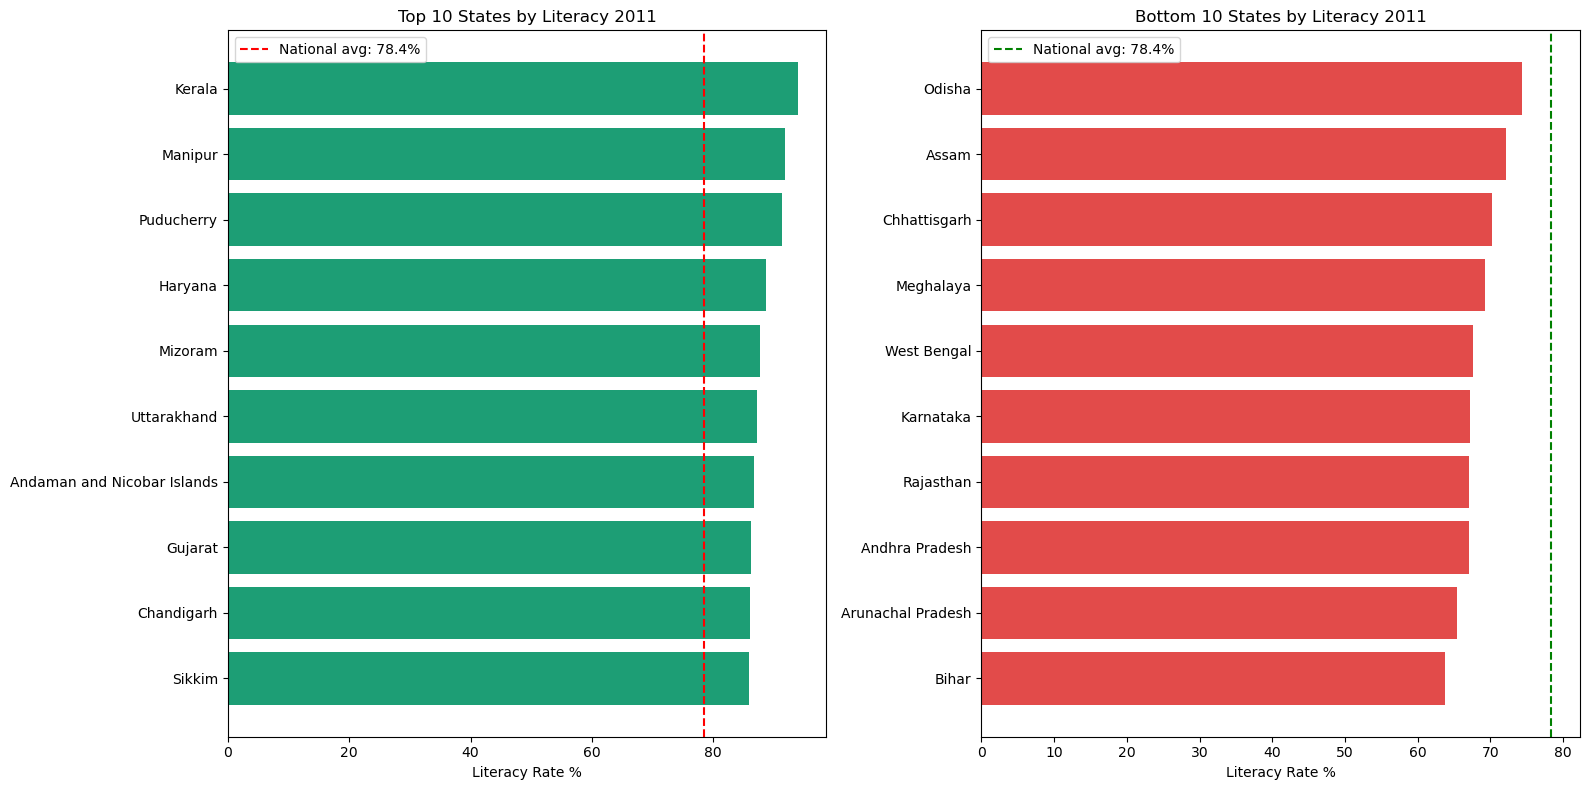

State rankings plot saved.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_lit = df2.nlargest(10, 'literacy_2011')[['state','literacy_2011']]
axes[0].barh(top_lit['state'][::-1], top_lit['literacy_2011'][::-1], color='#1D9E75')
axes[0].set_title('Top 10 States by Literacy 2011')
axes[0].set_xlabel('Literacy Rate %')
axes[0].axvline(x=df2['literacy_2011'].mean(), color='red', linestyle='--',
                label=f"National avg: {df2['literacy_2011'].mean():.1f}%")
axes[0].legend()

bot_lit = df2.nsmallest(10, 'literacy_2011')[['state','literacy_2011']]
axes[1].barh(bot_lit['state'], bot_lit['literacy_2011'], color='#E24B4A')
axes[1].set_title('Bottom 10 States by Literacy 2011')
axes[1].set_xlabel('Literacy Rate %')
axes[1].axvline(x=df2['literacy_2011'].mean(), color='green', linestyle='--',
                label=f"National avg: {df2['literacy_2011'].mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\sahil\india_project\screenshots\03_state_rankings.png', dpi=150)
plt.show()
print("State rankings plot saved.")

In [19]:
def classify_state(row):
    high_lit   = row['literacy_2011'] >= df2['literacy_2011'].median()
    high_unemp = row['unemployment_2011'] >= df2['unemployment_2011'].median()
    if high_lit and not high_unemp:
        return 'High Literacy Low Unemployment'
    elif high_lit and high_unemp:
        return 'High Literacy High Unemployment'
    elif not high_lit and not high_unemp:
        return 'Low Literacy Low Unemployment'
    else:
        return 'Low Literacy High Unemployment'

df2['category'] = df2.apply(classify_state, axis=1)
print(df2[['state','literacy_2011','unemployment_2011','category']].to_string())
print()
print(df2['category'].value_counts())

                          state  literacy_2011  unemployment_2011                         category
0   Andaman and Nicobar Islands          86.63                 54  High Literacy High Unemployment
1                Andhra Pradesh          67.02                 12    Low Literacy Low Unemployment
2             Arunachal Pradesh          65.39                 17    Low Literacy Low Unemployment
3                         Assam          72.19                 45   Low Literacy High Unemployment
4                         Bihar          63.82                 32   Low Literacy High Unemployment
5                    Chandigarh          86.05                 24  High Literacy High Unemployment
6                  Chhattisgarh          70.28                  8    Low Literacy Low Unemployment
7                         Delhi          76.24                 78   Low Literacy High Unemployment
8                           Goa          79.63                 51  High Literacy High Unemployment
9         

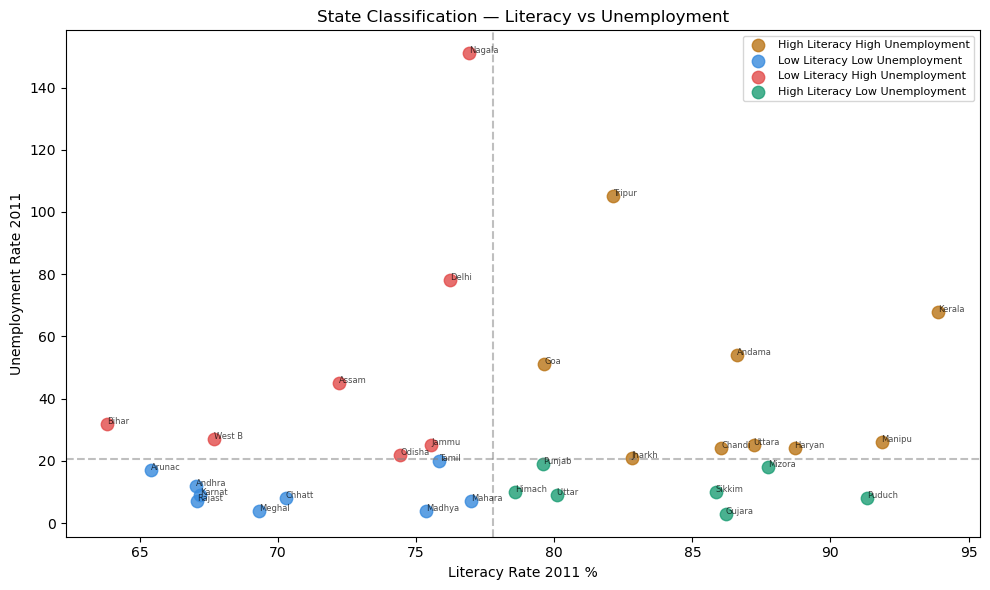

State classification plot saved.


In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    'High Literacy Low Unemployment'  : '#1D9E75',
    'High Literacy High Unemployment' : '#BA7517',
    'Low Literacy Low Unemployment'   : '#378ADD',
    'Low Literacy High Unemployment'  : '#E24B4A'
}

for category in df2['category'].unique():
    mask = df2['category'] == category
    ax.scatter(df2[mask]['literacy_2011'], df2[mask]['unemployment_2011'],
               label=category, color=colors[category], s=80, alpha=0.8)

for _, row in df2.iterrows():
    ax.annotate(row['state'][:6], (row['literacy_2011'], row['unemployment_2011']),
                fontsize=6, alpha=0.7)

ax.axvline(x=df2['literacy_2011'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=df2['unemployment_2011'].median(), color='gray', linestyle='--', alpha=0.5)
ax.set_title('State Classification — Literacy vs Unemployment')
ax.set_xlabel('Literacy Rate 2011 %')
ax.set_ylabel('Unemployment Rate 2011')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(r'C:\Users\sahil\india_project\screenshots\04_state_classification.png', dpi=150)
plt.show()
print("State classification plot saved.")

In [ ]:
engine = create_engine(
    'mssql+pyodbc://SAHIL\/IndiaEducationDB'
    '?driver=ODBC+Driver+17+for+SQL+Server'
    '&trusted_connection=yes'
)

df1.to_sql(name='dropout_rates', con=engine, if_exists='replace', index=False)
df2.to_sql(name='state_indicators', con=engine, if_exists='replace', index=False)
df3_clean.to_sql(name='education_stats', con=engine, if_exists='replace', index=False)

print("All 3 tables loaded to SQL Server.")